# Phase 3 v11 - MLP Without looking_down

**Experiment:** Drop `looking_down` entirely from the suspicious classes.
Windows labelled `looking_down` are relabelled as `normal`.

**Hypothesis:** looking_down is the biggest false alarm source (93/263 suspicious
predictions on V01 were looking_down, but only 1 GT event was looking_down).
Removing it should dramatically cut false alarms while barely affecting detection
of actual cheating events.

**Stage 2 classes:** `head_turn`, `lateral_movement` (2 classes instead of 3)

In [1]:
import os, io, pickle, warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
warnings.filterwarnings('ignore'); sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
DATA_DIR   = '/home/sagemaker-user/exam_proctoring_dataset'
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
POSES_DIR  = os.path.join(DATA_DIR, 'poses')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURES_CHECKPOINT_CANDIDATES = [
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint_filtered.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v9_manual_clip_only_target_review_checkpoint.pkl'),
]
REVIEW_CSV_CANDIDATES = [
    os.path.join(DATA_DIR, 'review_target_person_v10', 'target_person_review.csv'),
    os.path.join(DATA_DIR, 'review_target_person_v9',  'target_person_review.csv'),
]

MERGE_MAP = {
    'normal': 'normal', 'looking_down': 'looking_down',
    'leaning_to_neighbor': 'lateral_movement', 'passing_note': 'lateral_movement',
    'looking_sideways': 'head_turn', 'talking_to_neighbor': 'head_turn',
}

SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

def save_ckpt(obj, path):
    with open(path, 'wb') as f: pickle.dump(obj, f)
    print(f'  Saved: {os.path.basename(path)}')

def load_ckpt(path):
    if not os.path.exists(path): return None
    with open(path, 'rb') as f: return pickle.load(f)

def scaler_to_bytes(sc):
    buf = io.BytesIO(); pickle.dump(sc, buf); return buf.getvalue()

H1=128; H2=64; DROP=0.4; BS=64
VER = 'v11'

# Only 2 suspicious classes — looking_down is relabelled as normal
SUSPICIOUS_CLASSES = ['head_turn', 'lateral_movement']
ALL_CLASSES = ['normal'] + SUSPICIOUS_CLASSES
NUM_SUS = len(SUSPICIOUS_CLASSES)

# Modified merge map: looking_down → normal
MERGE_MAP_V11 = {
    'normal': 'normal',
    'looking_down': 'normal',  # KEY CHANGE: treated as normal
    'leaning_to_neighbor': 'lateral_movement',
    'passing_note': 'lateral_movement',
    'looking_sideways': 'head_turn',
    'talking_to_neighbor': 'head_turn',
}
print(f'Config: {ALL_CLASSES}')

Config: ['normal', 'head_turn', 'lateral_movement']


## Load Data & Apply Exclusions

In [3]:
# Load Phase 2 checkpoint
cached = None
for p in FEATURES_CHECKPOINT_CANDIDATES:
    if os.path.exists(p):
        cached = load_ckpt(p)
        print(f'Loaded: {os.path.basename(p)}')
        break
if cached is None:
    raise FileNotFoundError('No Phase 2 checkpoint found.')

all_features = cached['features']
all_labels_7 = cached['labels_7class']
all_labels_2 = cached['labels_binary']
all_meta     = cached['meta']
FULL_FEAT_NAMES = cached['full_feature_names']
NUM_FEATURES = all_features.shape[1]
print(f'Loaded {len(all_features)} windows, {NUM_FEATURES} features')

Loaded: features_v9_manual_clip_only_target_review_checkpoint.pkl
Loaded 3496 windows, 78 features


In [4]:
# Apply review exclusions
excluded_keys = set()
for p in REVIEW_CSV_CANDIDATES:
    if not os.path.exists(p): continue
    try:
        rdf = pd.read_csv(p, encoding='utf-8-sig')
        if 'review_status' in rdf.columns:
            status = rdf['review_status'].fillna('').astype(str).str.strip().str.lower()
            for _, row in rdf[status.isin(['exclude', 'excluded'])].iterrows():
                excluded_keys.add((str(row['clip_stem']).strip(), int(row['window_index'])))
            if excluded_keys: print(f'  {len(excluded_keys)} exclusions from {os.path.basename(p)}')
        break
    except: pass

if excluded_keys:
    keep = np.ones(len(all_features), dtype=bool)
    for i, m in enumerate(all_meta):
        if (str(m['clip_stem']).strip(), int(m['window_index'])) in excluded_keys:
            keep[i] = False
    n_removed = int((~keep).sum())
    if n_removed > 0:
        all_features = all_features[keep]
        all_labels_7 = all_labels_7[keep]
        all_labels_2 = all_labels_2[keep]
        all_meta = [m for m, k in zip(all_meta, keep) if k]
        print(f'  Removed {n_removed} windows')
print(f'Post-exclusion: {len(all_features)} windows')

  130 exclusions from target_person_review.csv
  Removed 130 windows
Post-exclusion: 3366 windows


## Apply Class Merge (looking_down → normal)

In [5]:
all_labels_merged = np.array([MERGE_MAP_V11[l] for l in all_labels_7])
all_labels_2_new = np.where(all_labels_merged == 'normal', 'normal', 'suspicious')

print('Class distribution after relabelling looking_down as normal:')
for l, c in zip(*np.unique(all_labels_merged, return_counts=True)):
    print(f'  {l:<20s} {c:5d} ({c/len(all_labels_merged)*100:.1f}%)')
print(f'\nBinary: normal={(all_labels_2_new=="normal").sum()}, suspicious={(all_labels_2_new=="suspicious").sum()}')

Class distribution after relabelling looking_down as normal:
  head_turn              486 (14.4%)
  lateral_movement       374 (11.1%)
  normal                2506 (74.5%)

Binary: normal=2506, suspicious=860


## Split

In [6]:
def stratified_scenario_split(meta_list, seed=SEED):
    rng = np.random.default_rng(seed)
    meta_df = pd.DataFrame(meta_list)
    scenario_df = meta_df[['scenario_id', 'original_behavior']].drop_duplicates()
    train_ids, val_ids, test_ids = [], [], []
    for cls in sorted(scenario_df['original_behavior'].unique()):
        ids = scenario_df.loc[scenario_df['original_behavior'] == cls, 'scenario_id'].unique().tolist()
        rng.shuffle(ids)
        n = len(ids)
        if n < 3: raise ValueError(f"Class '{cls}' has only {n} scenarios")
        n_test = max(1, round(n * 0.15)); n_val = max(1, round(n * 0.15))
        n_train = n - n_val - n_test
        while n_train < 1:
            if n_test > n_val and n_test > 1: n_test -= 1
            elif n_val > 1: n_val -= 1
            else: break
            n_train = n - n_val - n_test
        train_ids.extend(ids[:n_train]); val_ids.extend(ids[n_train:n_train+n_val])
        test_ids.extend(ids[n_train+n_val:])
    return set(train_ids), set(val_ids), set(test_ids)

train_scenarios, val_scenarios, test_scenarios = stratified_scenario_split(all_meta)
meta_df = pd.DataFrame(all_meta)
tr_m = meta_df['scenario_id'].isin(train_scenarios).values
va_m = meta_df['scenario_id'].isin(val_scenarios).values
te_m = meta_df['scenario_id'].isin(test_scenarios).values
print(f'Split: Train={tr_m.sum()}, Val={va_m.sum()}, Test={te_m.sum()}')

Split: Train=2234, Val=557, Test=575


## Model & Training Function

In [7]:
class MLP(nn.Module):
    def __init__(self, inp, h1, h2, out, drop=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(inp), nn.Linear(inp, h1), nn.ReLU(), nn.Dropout(drop),
            nn.BatchNorm1d(h1), nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h2, out),
        )
    def forward(self, x): return self.net(x)

In [8]:
def train_model(model, tr_dl, va_dl, n_cls, save_path, max_ep=150, patience=25, lr=1e-3):
    cc = np.zeros(n_cls)
    for _, yb in tr_dl:
        for y in yb.numpy(): cc[y] += 1
    cw = 1.0 / np.maximum(cc, 1); cw = cw / cw.sum() * n_cls
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(cw).to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
    hist = {'t_loss':[], 'v_loss':[], 't_f1':[], 'v_f1':[]}
    best_f1, pat_ctr = 0.0, 0
    for ep in range(max_ep):
        model.train(); tl, tp, tt = [], [], []
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(); out = model(xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl.append(loss.item()); tp.extend(out.argmax(1).cpu().numpy()); tt.extend(yb.cpu().numpy())
        model.eval(); vl, vp, vt = [], [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb); loss = criterion(out, yb)
                vl.append(loss.item()); vp.extend(out.argmax(1).cpu().numpy()); vt.extend(yb.cpu().numpy())
        t_f1 = f1_score(tt, tp, average='macro', zero_division=0)
        v_f1 = f1_score(vt, vp, average='macro', zero_division=0)
        hist['t_loss'].append(float(np.mean(tl))); hist['v_loss'].append(float(np.mean(vl)))
        hist['t_f1'].append(t_f1); hist['v_f1'].append(v_f1)
        scheduler.step(v_f1)
        improved = ''
        if v_f1 > best_f1:
            best_f1 = v_f1; pat_ctr = 0; improved = ' *'
            torch.save({'state_dict': model.state_dict(), 'epoch': ep, 'val_f1': v_f1}, save_path)
        else: pat_ctr += 1
        if (ep+1) % 10 == 0 or ep == 0 or improved:
            print(f'  Ep {ep+1:3d}  loss={np.mean(tl):.4f}/{np.mean(vl):.4f}  F1={t_f1:.4f}/{v_f1:.4f}{improved}')
        if pat_ctr >= patience:
            print(f'  Early stopping at epoch {ep+1}'); break
    print(f'  Best val F1: {best_f1:.4f}')
    return hist, best_f1

def plot_curves(hist, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist['t_loss'], label='Train', color='steelblue')
    axes[0].plot(hist['v_loss'], label='Val', color='coral')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['t_f1'], label='Train', color='steelblue')
    axes[1].plot(hist['v_f1'], label='Val', color='coral')
    axes[1].set_title(f'{title} — Macro F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches='tight'); plt.show()

## Stage 1: Normal vs Suspicious

Stage 1: normal=1624, suspicious=610
Params: 18,910
  Ep   1  loss=0.6061/0.5482  F1=0.6761/0.6434 *
  Ep   3  loss=0.4195/0.5276  F1=0.8119/0.6550 *
  Ep   4  loss=0.3595/0.5091  F1=0.8442/0.6895 *
  Ep   6  loss=0.3105/0.4684  F1=0.8683/0.7067 *
  Ep   7  loss=0.2766/0.4535  F1=0.8880/0.7270 *
  Ep  10  loss=0.2567/0.4373  F1=0.8872/0.7432 *
  Ep  16  loss=0.1970/0.3903  F1=0.9203/0.7581 *
  Ep  20  loss=0.1852/0.4225  F1=0.9235/0.7368
  Ep  30  loss=0.1389/0.4397  F1=0.9515/0.7458
  Ep  40  loss=0.1137/0.4262  F1=0.9584/0.7589 *
  Ep  45  loss=0.1088/0.4202  F1=0.9579/0.7685 *
  Ep  46  loss=0.1133/0.4180  F1=0.9548/0.7708 *
  Ep  49  loss=0.1074/0.4209  F1=0.9611/0.7730 *
  Ep  50  loss=0.1207/0.4419  F1=0.9521/0.7585
  Ep  51  loss=0.1167/0.4135  F1=0.9552/0.7883 *
  Ep  55  loss=0.1086/0.4090  F1=0.9584/0.7890 *
  Ep  60  loss=0.1108/0.4156  F1=0.9575/0.7534
  Ep  70  loss=0.1014/0.4540  F1=0.9570/0.7644
  Ep  80  loss=0.0900/0.4655  F1=0.9646/0.7593
  Early stopping at epoch 80


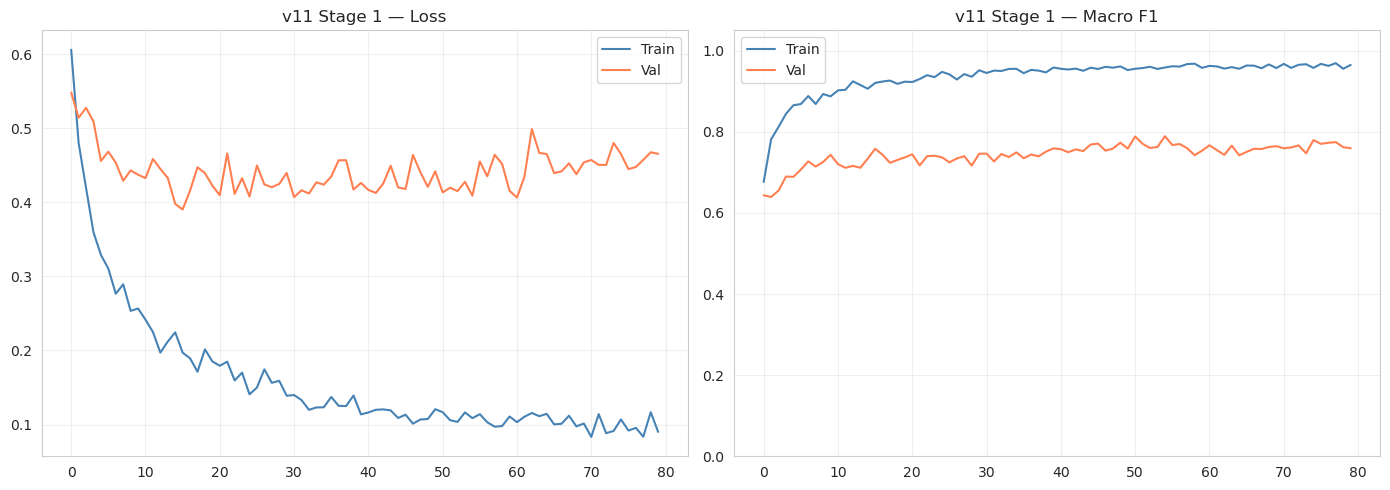

In [9]:
le1 = LabelEncoder(); le1.fit(['normal', 'suspicious'])
y1_all = le1.transform(all_labels_2_new)
sc1 = StandardScaler()
X1_tr = sc1.fit_transform(all_features[tr_m]).astype(np.float32)
X1_va = sc1.transform(all_features[va_m]).astype(np.float32)
X1_te = sc1.transform(all_features[te_m]).astype(np.float32)
y1_tr, y1_va, y1_te = y1_all[tr_m], y1_all[va_m], y1_all[te_m]

cc1 = np.bincount(y1_tr, minlength=2).astype(np.float64)
sw1 = (1.0/np.maximum(cc1,1))[y1_tr]; sw1 = sw1/sw1.sum()
sampler1 = WeightedRandomSampler(sw1, len(sw1), replacement=True)
dl1_tr = DataLoader(TensorDataset(torch.FloatTensor(X1_tr), torch.LongTensor(y1_tr)), batch_size=BS, sampler=sampler1)
dl1_va = DataLoader(TensorDataset(torch.FloatTensor(X1_va), torch.LongTensor(y1_va)), batch_size=BS, shuffle=False)
dl1_te = DataLoader(TensorDataset(torch.FloatTensor(X1_te), torch.LongTensor(y1_te)), batch_size=BS, shuffle=False)

print(f'Stage 1: normal={(y1_tr==0).sum()}, suspicious={(y1_tr==1).sum()}')

S1_PATH = os.path.join(OUTPUT_DIR, f'stage1_best_{VER}.pth')
model1 = MLP(NUM_FEATURES, H1, H2, 2, DROP).to(device)
print(f'Params: {sum(p.numel() for p in model1.parameters()):,}')
hist1, best_s1 = train_model(model1, dl1_tr, dl1_va, 2, S1_PATH)
plot_curves(hist1, f'{VER} Stage 1', f'{VER}_stage1_curves.png')

## Threshold Sweep

In [10]:
ckpt1 = torch.load(S1_PATH, map_location=device, weights_only=True)
model1.load_state_dict(ckpt1['state_dict']); model1.eval()
va_probs, te_probs = [], []
with torch.no_grad():
    for xb, _ in dl1_va:
        va_probs.append(torch.softmax(model1(xb.to(device)), 1).cpu().numpy())
    for xb, _ in dl1_te:
        te_probs.append(torch.softmax(model1(xb.to(device)), 1).cpu().numpy())
va_probs = np.vstack(va_probs); te_probs = np.vstack(te_probs)
p_sus_va = va_probs[:,1]; p_sus_te = te_probs[:,1]

best_thr, best_fb2 = 0.5, 0
for thr in np.arange(0.20, 0.82, 0.02):
    preds = (p_sus_va >= thr).astype(int)
    prec = float((preds[y1_va==1]==1).sum()) / max(float((preds==1).sum()), 1)
    rec = float((preds[y1_va==1]==1).sum()) / max(float((y1_va==1).sum()), 1)
    fb2 = 5*prec*rec / max(4*prec+rec, 1e-6)
    if fb2 > best_fb2: best_fb2 = fb2; best_thr = float(thr)
THRESHOLD = best_thr
print(f'Optimal threshold: {THRESHOLD:.2f} (F-beta2={best_fb2:.4f})')

Optimal threshold: 0.20 (F-beta2=0.7065)


## Stage 2: head_turn vs lateral_movement (2 classes)

Stage 2 train: {'head_turn': 345, 'lateral_movement': 265}
  Ep   1  loss=0.6369/0.5822  F1=0.6229/0.7901 *
  Ep   2  loss=0.5109/0.4820  F1=0.7916/0.8171 *
  Ep   3  loss=0.4684/0.4137  F1=0.7687/0.8426 *
  Ep   4  loss=0.3613/0.3629  F1=0.8557/0.8529 *
  Ep   5  loss=0.3186/0.3137  F1=0.8525/0.8793 *
  Ep   6  loss=0.2952/0.2869  F1=0.8720/0.9143 *
  Ep   7  loss=0.2641/0.2566  F1=0.8934/0.9231 *
  Ep  10  loss=0.2690/0.2754  F1=0.8883/0.9054
  Ep  20  loss=0.1012/0.3665  F1=0.9656/0.8785
  Ep  30  loss=0.0741/0.5283  F1=0.9770/0.8793
  Early stopping at epoch 32
  Best val F1: 0.9231


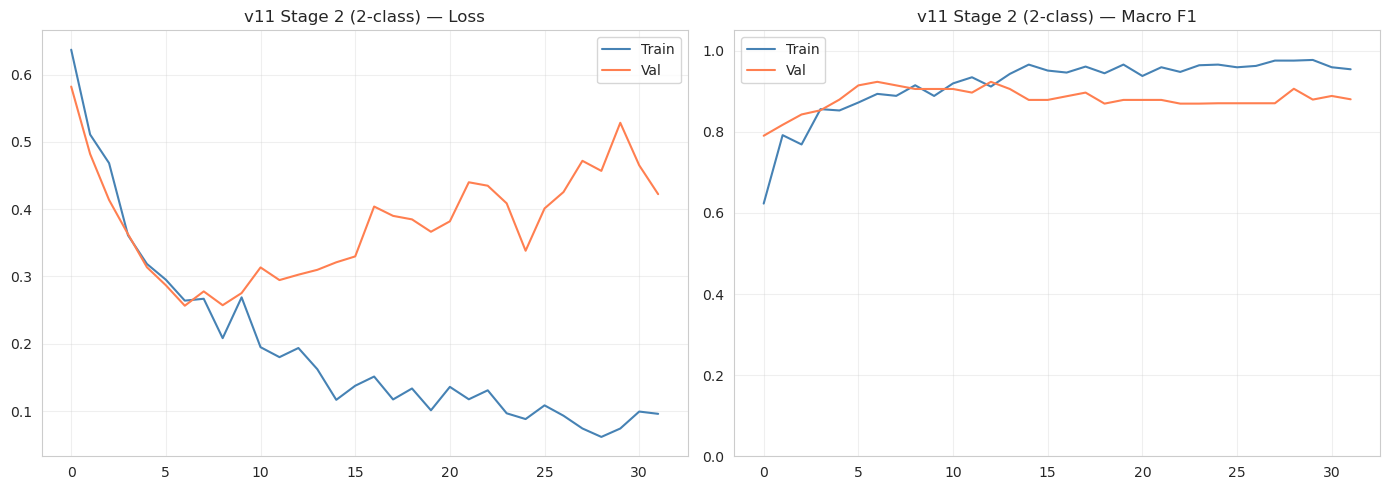

In [11]:
sus_mask = all_labels_2_new == 'suspicious'
X2_all = all_features[sus_mask]
y2_str = all_labels_merged[sus_mask]

le2 = LabelEncoder(); le2.fit(SUSPICIOUS_CLASSES)
y2_all = le2.transform(y2_str)

sids_sus = pd.DataFrame([m for m, s in zip(all_meta, sus_mask) if s])['scenario_id'].values
tr2 = np.isin(sids_sus, list(train_scenarios))
va2 = np.isin(sids_sus, list(val_scenarios))
te2 = np.isin(sids_sus, list(test_scenarios))

sc2 = StandardScaler()
X2_tr = sc2.fit_transform(X2_all[tr2]).astype(np.float32)
X2_va = sc2.transform(X2_all[va2]).astype(np.float32)
X2_te = sc2.transform(X2_all[te2]).astype(np.float32)
y2_tr, y2_va, y2_te = y2_all[tr2], y2_all[va2], y2_all[te2]

cc2 = np.bincount(y2_tr, minlength=NUM_SUS).astype(np.float64)
sw2 = (1.0/np.maximum(cc2,1))[y2_tr]; sw2 = sw2/sw2.sum()
dl2_tr = DataLoader(TensorDataset(torch.FloatTensor(X2_tr), torch.LongTensor(y2_tr)), batch_size=BS, sampler=WeightedRandomSampler(sw2, len(sw2), replacement=True))
dl2_va = DataLoader(TensorDataset(torch.FloatTensor(X2_va), torch.LongTensor(y2_va)), batch_size=BS, shuffle=False)
dl2_te = DataLoader(TensorDataset(torch.FloatTensor(X2_te), torch.LongTensor(y2_te)), batch_size=BS, shuffle=False)

print(f'Stage 2 train: {dict(zip(le2.classes_, np.bincount(y2_tr)))}')

S2_PATH = os.path.join(OUTPUT_DIR, f'stage2_best_{VER}.pth')
model2 = MLP(NUM_FEATURES, H1, H2, NUM_SUS, DROP).to(device)
hist2, best_s2 = train_model(model2, dl2_tr, dl2_va, NUM_SUS, S2_PATH)
plot_curves(hist2, f'{VER} Stage 2 (2-class)', f'{VER}_stage2_curves.png')

## Combined Evaluation


v11 COMBINED (threshold=0.20):
  Accuracy: 0.8243
  Macro F1: 0.6912

                  precision    recall  f1-score   support

       head_turn      0.505     0.657     0.571        70
lateral_movement      0.600     0.600     0.600        60
          normal      0.925     0.881     0.902       445

        accuracy                          0.824       575
       macro avg      0.677     0.713     0.691       575
    weighted avg      0.840     0.824     0.830       575



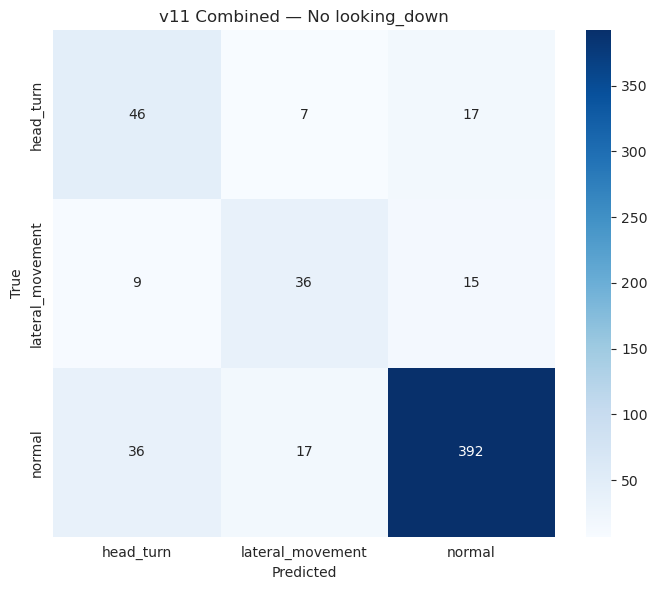


Inference package saved: inference_package_v11.pth


In [12]:
# Load best models
ckpt2 = torch.load(S2_PATH, map_location=device, weights_only=True)
model2.load_state_dict(ckpt2['state_dict']); model2.eval()

le_all = LabelEncoder(); le_all.fit(ALL_CLASSES)
y_te = le_all.transform(all_labels_merged[te_m])

# Stage 1 at optimal threshold
flagged = p_sus_te >= THRESHOLD
combined = np.full(len(p_sus_te), le_all.transform(['normal'])[0])
if flagged.sum() > 0:
    X_flag = sc2.transform(all_features[te_m][flagged]).astype(np.float32)
    s2p = []
    with torch.no_grad():
        for s in range(0, len(X_flag), BS):
            xb = torch.FloatTensor(X_flag[s:s+BS]).to(device)
            s2p.extend(model2(xb).argmax(1).cpu().numpy())
    for i, fi in enumerate(np.where(flagged)[0]):
        combined[fi] = le_all.transform([le2.classes_[s2p[i]]])[0]

acc = accuracy_score(y_te, combined)
f1 = f1_score(y_te, combined, average='macro', zero_division=0)
print(f'\n{VER} COMBINED (threshold={THRESHOLD:.2f}):')
print(f'  Accuracy: {acc:.4f}')
print(f'  Macro F1: {f1:.4f}')
print(f'\n{classification_report(y_te, combined, target_names=le_all.classes_, digits=3, zero_division=0)}')

cm = confusion_matrix(y_te, combined)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_all.classes_, yticklabels=le_all.classes_, ax=ax)
ax.set_title(f'{VER} Combined — No looking_down'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f'{VER}_combined_cm.png'), dpi=150, bbox_inches='tight'); plt.show()

# Save inference package
pkg = {
    'stage1_state_dict': model1.state_dict(), 'stage2_state_dict': model2.state_dict(),
    'stage1_scaler_bytes': scaler_to_bytes(sc1), 'stage2_scaler_bytes': scaler_to_bytes(sc2),
    'stage1_threshold': THRESHOLD,
    'model_config': {'input_dim': NUM_FEATURES, 'hidden1': H1, 'hidden2': H2, 'dropout': DROP, 'stage1_out': 2, 'stage2_out': NUM_SUS},
    'stage1_classes': ['normal','suspicious'], 'stage2_classes': list(le2.classes_), 'all_classes': ALL_CLASSES,
    'experiment': VER, 'test_accuracy': float(acc), 'test_macro_f1': float(f1),
    'stage1_best_val_f1': float(best_s1), 'stage2_best_val_f1': float(best_s2),
}
torch.save(pkg, os.path.join(OUTPUT_DIR, f'inference_package_{VER}.pth'))
print(f'\nInference package saved: inference_package_{VER}.pth')